In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("STEAM TOP 100 GAMES ANALYSIS")
print("==========================================")


STEAM TOP 100 GAMES ANALYSIS


In [ ]:
# Load the dataset
df = pd.read_csv('steam_top_100.csv')
print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")


Data loaded successfully!
Dataset shape: (100, 7)


In [ ]:
# Block 2: Basic Data Exploration
print("\nBASIC DATA EXPLORATION")
print("==========================================")

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

print(f"\nTotal number of games: {len(df)}")
print(f"Columns in dataset: {list(df.columns)}")


BASIC DATA EXPLORATION
First 5 rows of the dataset:
   Steam id                              Game  Current players  \
0       730  Counter-Strike: Global Offensive           736875   
1       570                            Dota 2           580933   
2   1063730                         New World           243815   
3   1172470                      Apex Legends           121313   
4       440                   Team Fortress 2           104477   

   Peak players today Release date   Review summary  Total reviews  
0              775266    21-Aug-12    Very Positive      5993058.0  
1              649690    09-Jul-13    Very Positive      1599180.0  
2              307146    28-Sep-21  Mostly Positive       145931.0  
3              245235    04-Nov-20    Very Positive       338236.0  
4              111884    10-Oct-07    Very Positive       821568.0  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column

In [ ]:
# Block 3: Data Cleaning and Preparation
print("\nDATA CLEANING AND PREPARATION")
print("==========================================")

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Create a clean copy of the dataframe
df_clean = df.copy()

# Handle missing values
df_clean['Release date'] = df_clean['Release date'].fillna('Unknown')
df_clean['Review summary'] = df_clean['Review summary'].fillna('Not Rated')
df_clean['Total reviews'] = df_clean['Total reviews'].fillna(0)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())


DATA CLEANING AND PREPARATION
Missing values in each column:
Steam id              0
Game                  0
Current players       0
Peak players today    0
Release date          1
Review summary        1
Total reviews         1
dtype: int64

Missing values after cleaning:
Steam id              0
Game                  0
Current players       0
Peak players today    0
Release date          0
Review summary        0
Total reviews         0
dtype: int64


In [ ]:
# Block 4: Popular Games Analysis
print("\nPOPULAR GAMES ANALYSIS")
print("==========================================")

# Top 10 games by current players
top_10_current = df_clean.nlargest(10, 'Current players')
print("TOP 10 GAMES BY CURRENT PLAYERS:")
for i, row in top_10_current.iterrows():
    print(f"{row['Game']} - {row['Current players']:,} players")

print("\n" + "-" * 50)

# Top 10 games by peak players
top_10_peak = df_clean.nlargest(10, 'Peak players today')
print("TOP 10 GAMES BY PEAK PLAYERS TODAY:")
for i, row in top_10_peak.iterrows():
    print(f"{row['Game']} - {row['Peak players today']:,} players")


POPULAR GAMES ANALYSIS
TOP 10 GAMES BY CURRENT PLAYERS:
Counter-Strike: Global Offensive - 736,875 players
Dota 2 - 580,933 players
New World - 243,815 players
Apex Legends - 121,313 players
Team Fortress 2 - 104,477 players
PUBG: BATTLEGROUNDS - 103,354 players
Rust - 86,156 players
MIR4 - 82,361 players
Grand Theft Auto V - 82,189 players
Path of Exile - 56,781 players

--------------------------------------------------
TOP 10 GAMES BY PEAK PLAYERS TODAY:
Counter-Strike: Global Offensive - 775,266 players
Dota 2 - 649,690 players
New World - 307,146 players
PUBG: BATTLEGROUNDS - 293,759 players
Apex Legends - 245,235 players
Team Fortress 2 - 111,884 players
Rust - 110,489 players
Grand Theft Auto V - 102,182 players
MIR4 - 91,872 players
NARAKA: BLADEPOINT - 83,335 players


In [ ]:
# Block 5: Review Analysis
print("\nREVIEW ANALYSIS")
print("==========================================")

# Review summary distribution
review_counts = df_clean['Review summary'].value_counts()
print("REVIEW SUMMARY DISTRIBUTION:")
for review_type, count in review_counts.items():
    percentage = (count / len(df_clean)) * 100
    print(f"{review_type}: {count} games ({percentage:.1f}%)")

print("\n" + "-" * 50)

# Games with different review types
very_positive = df_clean[df_clean['Review summary'] == 'Very Positive']
mixed = df_clean[df_clean['Review summary'] == 'Mixed']
overwhelming = df_clean[df_clean['Review summary'] == 'Overwhelmingly Positive']

print(f"Games with 'Very Positive' reviews: {len(very_positive)}")
print(f"Games with 'Mixed' reviews: {len(mixed)}")
print(f"Games with 'Overwhelmingly Positive' reviews: {len(overwhelming)}")


REVIEW ANALYSIS
REVIEW SUMMARY DISTRIBUTION:
Very Positive: 58 games (58.0%)
Overwhelmingly Positive: 25 games (25.0%)
Mostly Positive: 12 games (12.0%)
Mixed: 4 games (4.0%)
Not Rated: 1 games (1.0%)

--------------------------------------------------
Games with 'Very Positive' reviews: 58
Games with 'Mixed' reviews: 4
Games with 'Overwhelmingly Positive' reviews: 25


In [ ]:
# Block 6: Player Statistics
print("\nPLAYER STATISTICS")
print("==========================================")

print(f"Highest current players: {df_clean['Current players'].max():,}")
print(f"Lowest current players: {df_clean['Current players'].min():,}")
print(f"Average current players: {df_clean['Current players'].mean():,.0f}")
print(f"Total current players across all games: {df_clean['Current players'].sum():,}")

print(f"\nHighest peak players: {df_clean['Peak players today'].max():,}")
print(f"Average peak players: {df_clean['Peak players today'].mean():,.0f}")

print(f"\nMost reviewed game: {df_clean['Total reviews'].max():,} reviews")
print(f"Average reviews per game: {df_clean['Total reviews'].mean():,.0f}")


PLAYER STATISTICS
Highest current players: 736,875
Lowest current players: 6,724
Average current players: 39,954
Total current players across all games: 3,995,437

Highest peak players: 775,266
Average peak players: 52,364

Most reviewed game: 5,993,058.0 reviews
Average reviews per game: 266,926


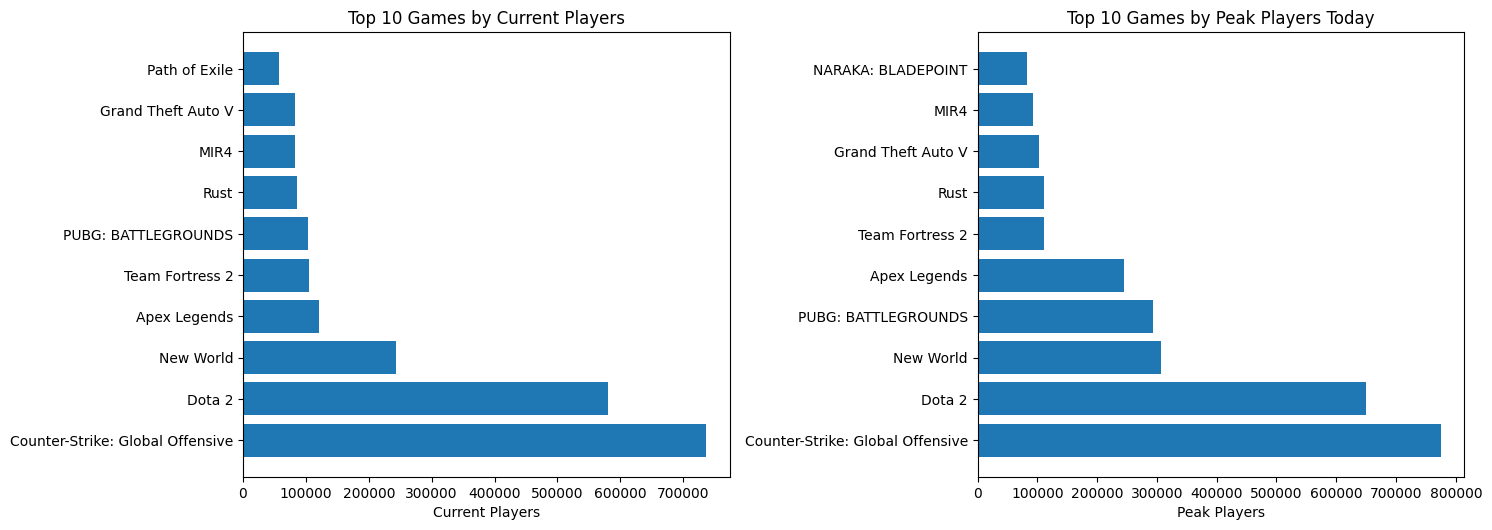

In [ ]:
# Block 7: Visualization 1 - Top Games
plt.figure(figsize=(15, 10))

# Chart 1: Top 10 games by current players
plt.subplot(2, 2, 1)
top_10_plot = df_clean.nlargest(10, 'Current players')
plt.barh(top_10_plot['Game'], top_10_plot['Current players'])
plt.title('Top 10 Games by Current Players')
plt.xlabel('Current Players')
plt.tight_layout()

# Chart 2: Top 10 games by peak players
plt.subplot(2, 2, 2)
top_10_peak_plot = df_clean.nlargest(10, 'Peak players today')
plt.barh(top_10_peak_plot['Game'], top_10_peak_plot['Peak players today'])
plt.title('Top 10 Games by Peak Players Today')
plt.xlabel('Peak Players')
plt.tight_layout()

plt.show()

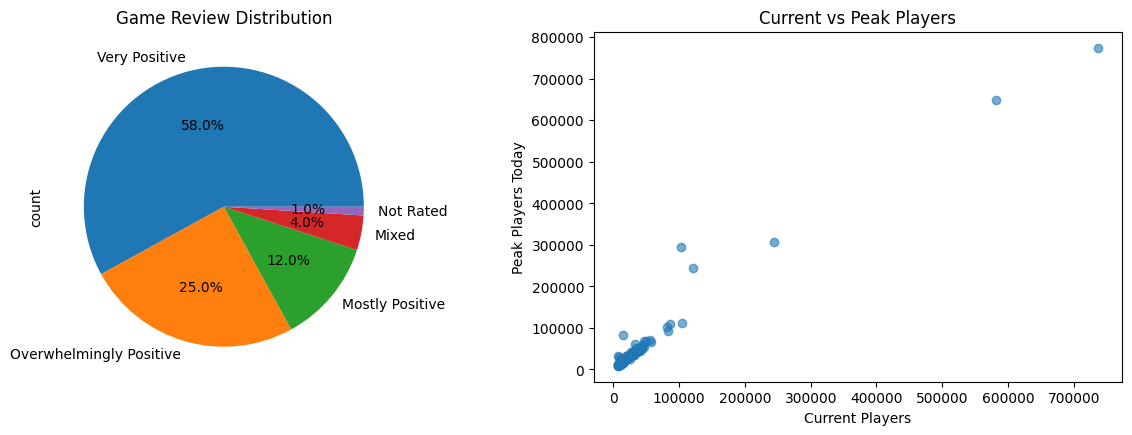

In [ ]:
# Block 8: Visualization 2 - Reviews and Distribution
plt.figure(figsize=(15, 10))

# Chart 3: Review distribution
plt.subplot(2, 2, 1)
review_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Game Review Distribution')

# Chart 4: Current vs Peak players scatter plot
plt.subplot(2, 2, 2)
plt.scatter(df_clean['Current players'], df_clean['Peak players today'], alpha=0.6)
plt.title('Current vs Peak Players')
plt.xlabel('Current Players')
plt.ylabel('Peak Players Today')

plt.show()

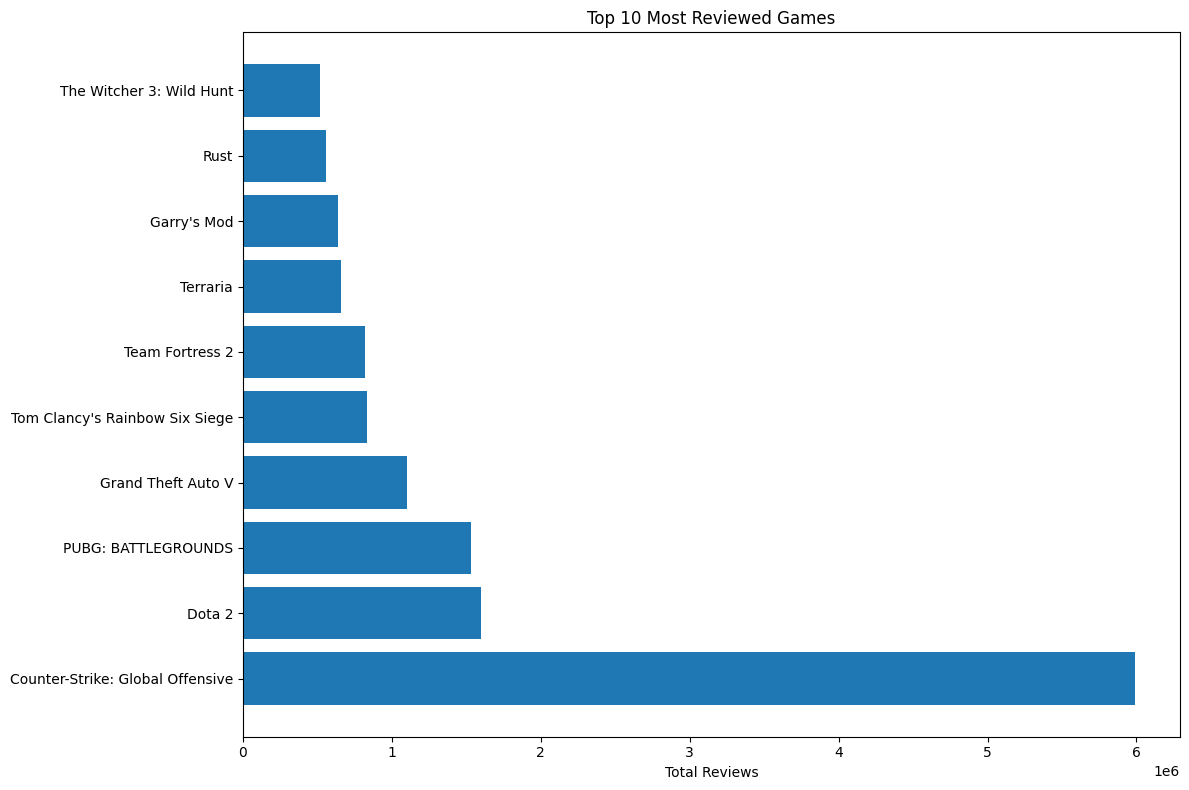

In [ ]:
# Block 9: Visualization 3 - Most Reviewed Games
plt.figure(figsize=(12, 8))

# Chart 5: Top 10 most reviewed games
top_reviews = df_clean.nlargest(10, 'Total reviews')
plt.barh(top_reviews['Game'], top_reviews['Total reviews'])
plt.title('Top 10 Most Reviewed Games')
plt.xlabel('Total Reviews')
plt.tight_layout()

plt.show()

In [ ]:
# Block 10: Advanced Analysis
print("\nADVANCED ANALYSIS")
print("==========================================")

# Calculate player retention ratio
df_clean['Retention_ratio'] = df_clean['Current players'] / df_clean['Peak players today']

# Games with high retention (current players close to peak)
high_retention = df_clean[df_clean['Retention_ratio'] > 0.8]
print(f"Games with high player retention (>80%): {len(high_retention)}")

print("\nTop 5 games with highest player retention:")
high_retention_top = high_retention.nlargest(5, 'Retention_ratio')
for i, row in high_retention_top.iterrows():
    print(f"{row['Game']} - {row['Retention_ratio']:.2f} retention ratio")

# Games with low retention
low_retention = df_clean[df_clean['Retention_ratio'] < 0.3]
print(f"\nGames with low player retention (<30%): {len(low_retention)}")

print("\nAnalysis complete!")


ADVANCED ANALYSIS
Games with high player retention (>80%): 34

Top 5 games with highest player retention:
Counter-Strike - 0.97 retention ratio
Cookie Clicker - 0.96 retention ratio
eFootball PES 2021 SEASON UPDATE - 0.96 retention ratio
F1 2021 - 0.95 retention ratio
Counter-Strike: Global Offensive - 0.95 retention ratio

Games with low player retention (<30%): 3

Analysis complete!
